# Discrete Optimization — Swarm & ACO Visualization

This notebook visualizes how **biology-inspired** and **ACO** algorithms
tackle three classical discrete optimization problems:

| Problem | Objective | Solution Representation |
|---------|-----------|-------------------------|
| **TSP** | Minimise tour distance | Permutation of cities |
| **Knapsack** | Maximise value (within capacity) | Binary selection vector |
| **Graph Coloring** | Minimise edge conflicts | Integer color assignment |

We compare **ABC**, **CS**, **FA** (swarm), and
**Ant System**, **MMAS**, **ACS** (ant colony) on each problem,
plotting convergence curves, best-solution visualizations, and
pheromone heatmaps for the ACO variants.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

from AIP.problems.discrete import TSP, Knapsack, GraphColoring

# Swarm
from AIP.algorithm.natural.biology.abc import ArtificialBeeColony, ABCParameter
from AIP.algorithm.natural.biology.cs import CuckooSearch, CuckooSearchParameter
from AIP.algorithm.natural.biology.fa import FireflyAlgorithm, FireflyParameter

# ACO
from AIP.algorithm.natural.biology.aco.ant_system import AntSystem, AntSystemParameter
from AIP.algorithm.natural.biology.aco.mmas import MMAS, MMASParameter
from AIP.algorithm.natural.biology.aco.acs import ACS, ACSParameter

# Local search
from AIP.algorithm.local.HillClimbing import HillClimbing, HillClimbingParameter

# Physics-inspired
from AIP.algorithm.natural.physic.SA import SimulatedAnnealing, SimulatedAnnealingParameter
from AIP.algorithm.natural.physic.HS import HarmonySearch, HarmonySearchParameter

# Classical search
from AIP.algorithm.classical.AStar import AStarSearch
from AIP.algorithm.classical.BFS import BreadthFirstSearch
from AIP.algorithm.classical.DFS import DepthFirstSearch
from AIP.algorithm.classical.GreedyBestFirst import GreedyBestFirstSearch
from AIP.algorithm.classical.UCS import UniformCostSearch

print('Imports OK')

Imports OK


## Helper — Convergence Plot

In [2]:
def convergence_from_history(history, problem):
    """Compute running-best fitness from a list of best-solution snapshots
    or scalar fitness values (HC stores scalars directly)."""
    best = float('inf')
    curve = []
    for entry in history:
        if np.isscalar(entry) or (isinstance(entry, np.ndarray) and entry.ndim == 0):
            f = float(entry)
        else:
            f = float(problem.eval(entry))
        best = min(best, f)
        curve.append(best)
    return curve


def plot_convergence(results, problem, title='Convergence'):
    """Plot convergence curves for multiple algorithms.

    Parameters
    ----------
    results : list of (name, history)
    problem : Problem instance (for re-evaluation)
    """
    fig, ax = plt.subplots(figsize=(9, 4))
    for name, hist in results:
        curve = convergence_from_history(hist, problem)
        ax.plot(curve, label=name, linewidth=2)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Best Fitness')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def extract_classical_solution(algo, problem):
    """Extract solution array from a classical search algorithm's path result.

    Returns (solution_array, fitness) or (None, None) if no path found.
    """
    if algo.best_solution is None:
        return None, None
    decoded = problem.decode_path(algo.best_solution)
    if isinstance(problem, TSP):
        tour = np.array(decoded['tour'][:-1])  # strip return-to-start
        return tour, decoded['total_distance']
    elif isinstance(problem, Knapsack):
        sel = np.zeros(problem.n_items)
        for i in decoded['selected_items']:
            sel[i] = 1
        return sel, float(problem.eval(sel))
    elif isinstance(problem, GraphColoring):
        coloring = np.array(decoded['coloring'])
        return coloring, float(problem.eval(coloring))
    return None, None

---
# 1. Travelling Salesman Problem (TSP)

We use the **small** instance (10 cities) so tours can be drawn clearly.

In [3]:
tsp = TSP.create_small()
print(f'Cities: {tsp.n_cities}  —  {tsp.city_names}')
print(f'Distance matrix shape: {tsp.dist_matrix.shape}')

Cities: 10  —  ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']
Distance matrix shape: (10, 10)


### 1.1 Run All Algorithms on TSP

In [4]:
N_ITER_TSP = 100
np.random.seed(42)

# --- Swarm algorithms ---
abc_tsp = ArtificialBeeColony(
    ABCParameter(n_bees=30, limit=50, iteration=N_ITER_TSP), tsp, stat=True
)
abc_tsp.run()
print(f"ABC   best = {abc_tsp.best_fitness:.1f}")

cs_tsp = CuckooSearch(
    CuckooSearchParameter(n_nests=30, pa=0.25, alpha=1, beta=1.5, iteration=N_ITER_TSP),
    tsp,
    stat=True,
)
cs_tsp.run()
print(f"CS    best = {cs_tsp.best_fitness:.1f}")

fa_tsp = FireflyAlgorithm(
    FireflyParameter(
        n_fireflies=30,
        alpha=0.5,
        beta0=1.0,
        gamma=0.1,
        alpha_decay=0.97,
        cycle=N_ITER_TSP,
    ),
    tsp,
    stat=True,
)
fa_tsp.run()
print(f"FA    best = {fa_tsp.best_fitness:.1f}")

# --- ACO algorithms ---
as_tsp = AntSystem(
    AntSystemParameter(rho=0.5, m=20, q=100, alpha=1, beta=3, cycle=N_ITER_TSP), tsp
)
as_tsp.run()
print(f"AS    best = {as_tsp.best_fitness:.1f}")

mmas_tsp = MMAS(MMASParameter(rho=0.02, m=20, alpha=1, beta=3, cycle=N_ITER_TSP), tsp)
mmas_tsp.run()
print(f"MMAS  best = {mmas_tsp.best_fitness:.1f}")

acs_tsp = ACS(
    ACSParameter(rho=0.1, xi=0.1, m=20, q0=0.9, alpha=1, beta=3, cycle=N_ITER_TSP), tsp
)
acs_tsp.run()
print(f"ACS   best = {acs_tsp.best_fitness:.1f}")

# --- Local search ---
hc_tsp = HillClimbing(HillClimbingParameter(iteration=N_ITER_TSP), tsp)
hc_tsp.run()
print(f"HC    best = {hc_tsp.best_fitness:.1f}")

# --- Physics-inspired ---
sa_tsp = SimulatedAnnealing(
    SimulatedAnnealingParameter(
        initial_temperature=100,
        cooling_rate=0.95,
        min_temperature=0.01,
        max_iterations=N_ITER_TSP,
        n_flips=1,
    ),
    tsp,
)
sa_tsp.run()
print(f"SA    best = {sa_tsp.best_fitness:.1f}")

hs_tsp = HarmonySearch(
    HarmonySearchParameter(
        hms=30, hmcr=0.9, par=0.3, bw=0.1, max_iterations=N_ITER_TSP
    ),
    tsp,
)
hs_tsp.run()
print(f"HS    best = {hs_tsp.best_fitness:.1f}")

# --- Classical search (graph-based, no iteration limit) ---
astar_tsp = AStarSearch({}, tsp)
astar_tsp.run()
astar_tsp_sol, astar_tsp_fit = extract_classical_solution(astar_tsp, tsp)
print(f"A*    best = {astar_tsp_fit:.1f}")

bfs_tsp = BreadthFirstSearch({}, tsp)
bfs_tsp.run()
bfs_tsp_sol, bfs_tsp_fit = extract_classical_solution(bfs_tsp, tsp)
print(f"BFS   best = {bfs_tsp_fit:.1f}")

dfs_tsp = DepthFirstSearch({}, tsp)
dfs_tsp.run()
dfs_tsp_sol, dfs_tsp_fit = extract_classical_solution(dfs_tsp, tsp)
print(f"DFS   best = {dfs_tsp_fit:.1f}")

gbf_tsp = GreedyBestFirstSearch({}, tsp)
gbf_tsp.run()
gbf_tsp_sol, gbf_tsp_fit = extract_classical_solution(gbf_tsp, tsp)
print(f"GBF   best = {gbf_tsp_fit:.1f}")

ucs_tsp = UniformCostSearch({}, tsp)
ucs_tsp.run()
ucs_tsp_sol, ucs_tsp_fit = extract_classical_solution(ucs_tsp, tsp)
print(f"UCS   best = {ucs_tsp_fit:.1f}")

ABC   best = 264.6
CS    best = 264.6
FA    best = 279.3
AS    best = 264.6
MMAS  best = 264.6
ACS   best = 264.6
HC    best = 264.6
SA    best = 264.6
HS    best = 405.3
A*    best = 264.6
BFS   best = 497.8
DFS   best = 497.8
GBF   best = 523.3
UCS   best = 264.6


### 1.2 TSP Convergence Comparison

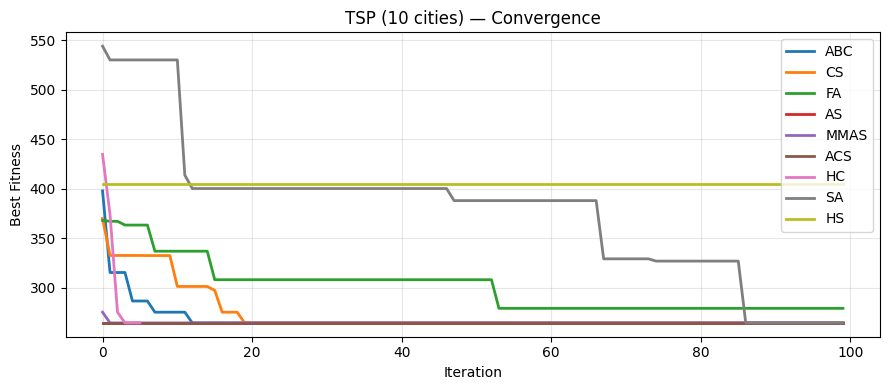

In [5]:
tsp_results = [
    ('ABC',  abc_tsp.history),
    ('CS',   cs_tsp.history),
    ('FA',   fa_tsp.history),
    ('AS',   as_tsp.history),
    ('MMAS', mmas_tsp.history),
    ('ACS',  acs_tsp.history),
    ('HC',   hc_tsp.history),
    ('SA',   sa_tsp.history),
    ('HS',   hs_tsp.history),
]
plot_convergence(tsp_results, tsp, title='TSP (10 cities) — Convergence')

### 1.3 Best Tour Visualization

Draw the best tour found by each algorithm on a circular city layout.
Classical search algorithms derive tours from graph-search paths.

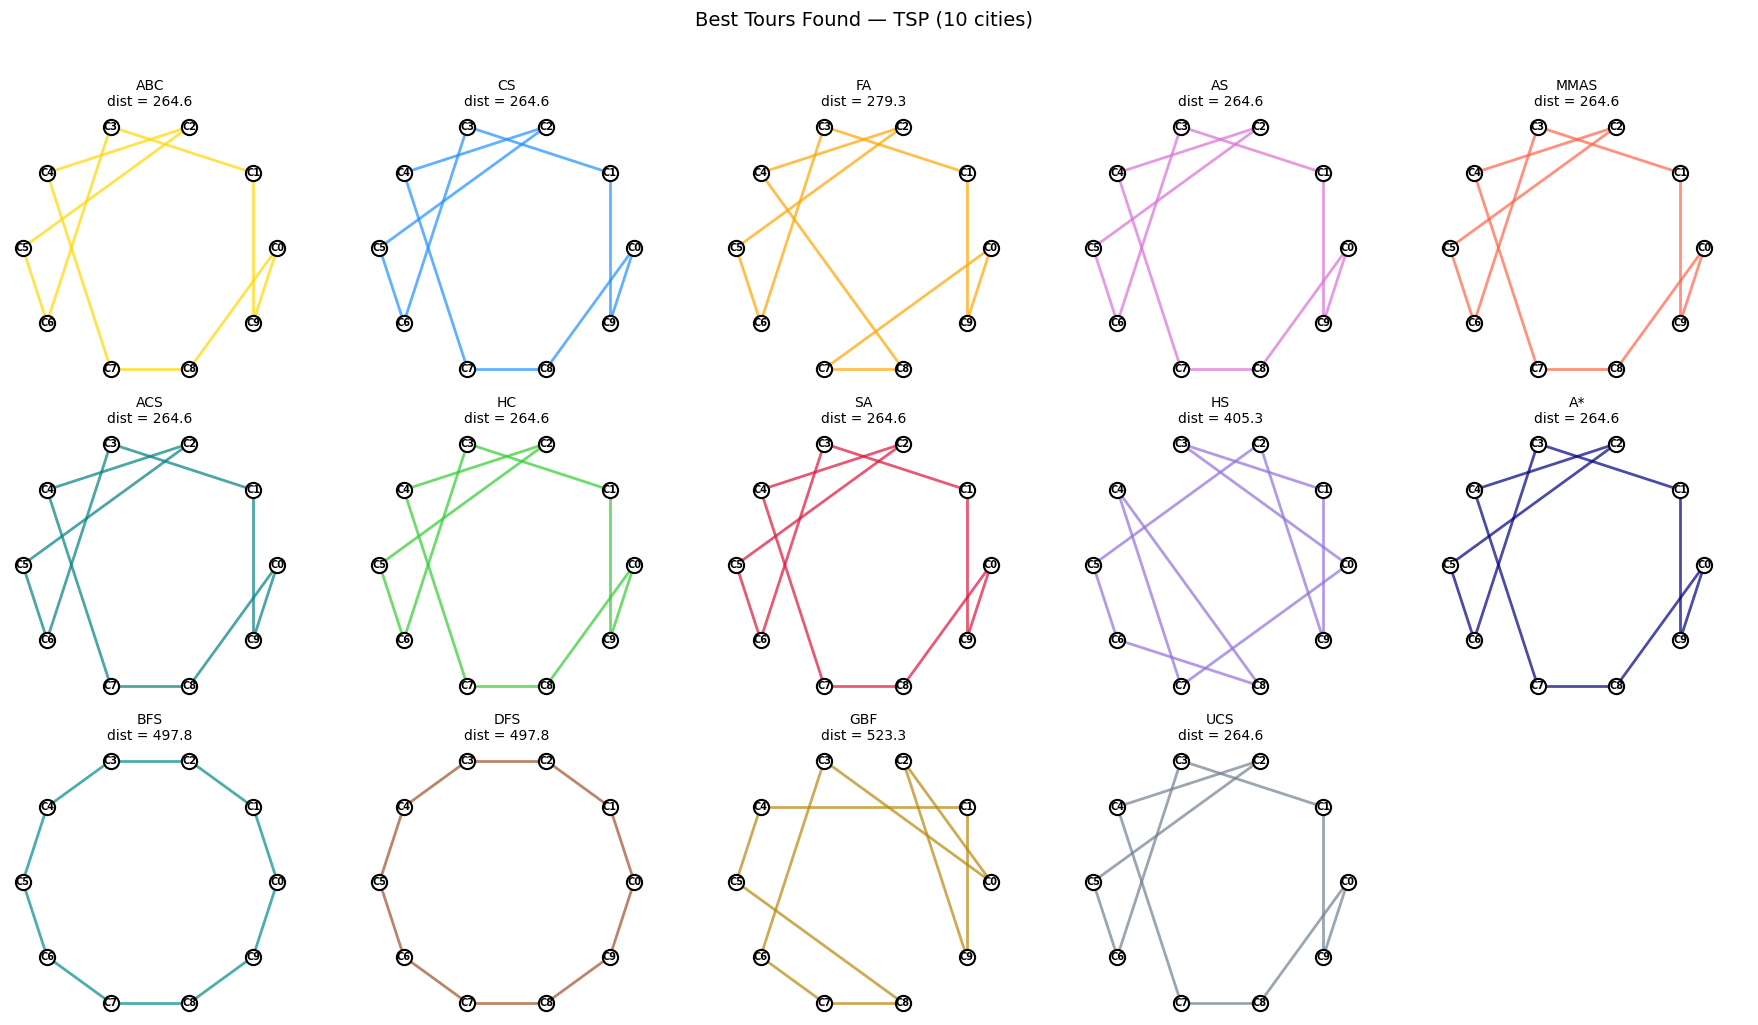

In [6]:
def draw_tsp_tour(ax, tour, tsp_problem, title='', color='steelblue'):
    """Draw a TSP tour on a circular layout."""
    n = tsp_problem.n_cities
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    coords = np.column_stack([np.cos(angles), np.sin(angles)])

    # Draw edges of the tour
    perm = tour.astype(int)
    for k in range(n):
        i, j = perm[k], perm[(k + 1) % n]
        ax.plot([coords[i, 0], coords[j, 0]],
               [coords[i, 1], coords[j, 1]],
               color=color, linewidth=2, alpha=0.7)

    # Draw city nodes
    ax.scatter(coords[:, 0], coords[:, 1], s=120, c='white',
              edgecolors='black', zorder=5, linewidths=1.5)
    for idx in range(n):
        ax.text(coords[idx, 0], coords[idx, 1],
               tsp_problem.city_names[idx],
               ha='center', va='center', fontsize=7, fontweight='bold', zorder=6)

    dist = float(tsp_problem.eval(tour))
    ax.set_title(f'{title}\ndist = {dist:.1f}', fontsize=10)
    ax.set_aspect('equal')
    ax.axis('off')


algorithms_tsp = [
    ('ABC',  abc_tsp.best_solution,  'gold'),
    ('CS',   cs_tsp.best_solution,   'dodgerblue'),
    ('FA',   fa_tsp.best_solution,   'orange'),
    ('AS',   as_tsp.best_solution,   'orchid'),
    ('MMAS', mmas_tsp.best_solution, 'tomato'),
    ('ACS',  acs_tsp.best_solution,  'teal'),
    ('HC',   hc_tsp.best_solution,   'limegreen'),
    ('SA',   sa_tsp.best_solution,   'crimson'),
    ('HS',   hs_tsp.best_solution,   'mediumpurple'),
    ('A*',   astar_tsp_sol,          'navy'),
    ('BFS',  bfs_tsp_sol,            'darkcyan'),
    ('DFS',  dfs_tsp_sol,            'sienna'),
    ('GBF',  gbf_tsp_sol,            'darkgoldenrod'),
    ('UCS',  ucs_tsp_sol,            'slategray'),
]

n_cols = 5
n_rows = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
axes = axes.flatten()
for idx, (name, sol, c) in enumerate(algorithms_tsp):
    draw_tsp_tour(axes[idx], sol, tsp, title=name, color=c)
# Hide unused subplot
axes[-1].axis('off')
fig.suptitle('Best Tours Found — TSP (10 cities)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 1.4 ACO Pheromone Heatmaps

Visualize the final pheromone matrices of Ant System, MMAS, and ACS.
Brighter cells indicate edges that ants strongly prefer.

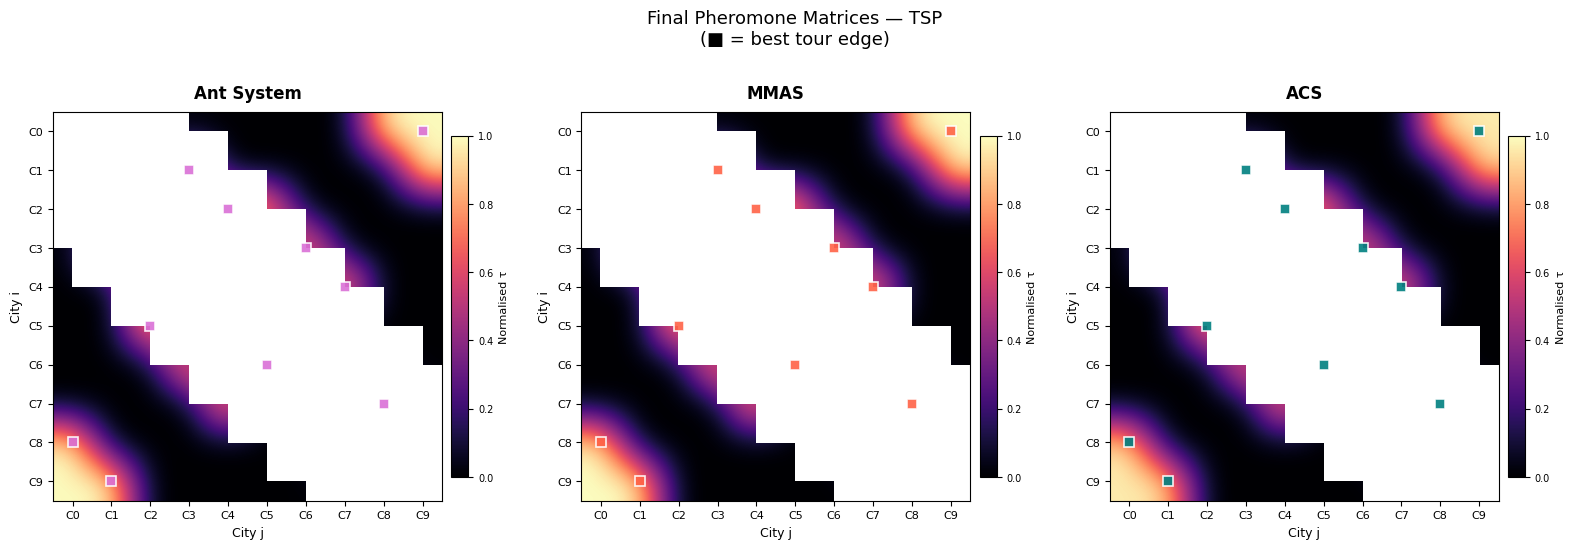

In [7]:
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

aco_data = [('Ant System', as_tsp, 'orchid'),
            ('MMAS', mmas_tsp, 'tomato'),
            ('ACS', acs_tsp, 'teal')]

for ax, (name, algo, color) in zip(axes, aco_data):
    tau = algo.tau.copy()
    np.fill_diagonal(tau, np.nan)  # mask diagonal (self-loops)

    # Normalise each matrix to [0, 1] for consistent comparison
    valid = tau[~np.isnan(tau)]
    tau_norm = (tau - np.nanmin(tau)) / (np.nanmax(tau) - np.nanmin(tau) + 1e-12)

    im = ax.imshow(tau_norm, cmap='magma', interpolation='bicubic',
                   vmin=0, vmax=1)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('City j', fontsize=9)
    ax.set_ylabel('City i', fontsize=9)
    ax.set_xticks(range(tsp.n_cities))
    ax.set_yticks(range(tsp.n_cities))
    ax.set_xticklabels(tsp.city_names, fontsize=8)
    ax.set_yticklabels(tsp.city_names, fontsize=8)

    # Overlay best tour edges as bright markers
    best = algo.best_solution.astype(int)
    for k in range(tsp.n_cities):
        i, j = best[k], best[(k + 1) % tsp.n_cities]
        ax.plot(j, i, 's', color=color, markersize=7, markeredgecolor='white',
                markeredgewidth=1.2, alpha=0.9)

    cb = plt.colorbar(im, ax=ax, shrink=0.82, pad=0.02)
    cb.set_label('Normalised τ', fontsize=8)
    cb.ax.tick_params(labelsize=7)

fig.suptitle('Final Pheromone Matrices — TSP\n(■ = best tour edge)',
             fontsize=13, y=1.04)
plt.tight_layout()
plt.show()

---
# 2. 0/1 Knapsack Problem

We use the **small** instance (20 items, capacity 270).

In [8]:
knapsack = Knapsack.create_small()
print(f'Items: {knapsack.n_items}   Capacity: {knapsack.capacity}')
print(f'Weights: {knapsack.weights}')
print(f'Values:  {knapsack.values}')

Items: 20   Capacity: 270.0
Weights: [ 5. 38. 33. 22. 22. 43.  5. 35. 10.  5. 26. 48. 37. 38. 36. 39. 26.  7.
 42. 23.]
Values:  [50. 37. 19. 92. 78. 64. 40. 82. 54. 44. 45. 23. 10. 55. 88.  7. 85. 82.
 28. 63.]


### 2.1 Run All Algorithms on Knapsack

In [10]:
N_ITER_KS = 150
np.random.seed(123)

# --- Swarm ---
abc_ks = ArtificialBeeColony(
    ABCParameter(n_bees=30, limit=50, iteration=N_ITER_KS), knapsack, stat=True
)
abc_ks.run()
print(f"ABC   best = {abc_ks.best_fitness:.1f}")

cs_ks = CuckooSearch(
    CuckooSearchParameter(n_nests=30, pa=0.25, alpha=1, beta=1.5, iteration=N_ITER_KS),
    knapsack,
    stat=True,
)
cs_ks.run()
print(f"CS    best = {cs_ks.best_fitness:.1f}")

fa_ks = FireflyAlgorithm(
    FireflyParameter(
        n_fireflies=30,
        alpha=0.5,
        beta0=0.1,
        gamma=1.0,
        alpha_decay=0.97,
        cycle=N_ITER_KS,
    ),
    knapsack,
    stat=True,
)
fa_ks.run()
print(f"FA    best = {fa_ks.best_fitness:.1f}")

# --- ACO ---
as_ks = AntSystem(
    AntSystemParameter(rho=0.5, m=20, q=100, alpha=1, beta=2, cycle=N_ITER_KS), knapsack
)
as_ks.run()
print(f"AS    best = {as_ks.best_fitness:.1f}")

mmas_ks = MMAS(
    MMASParameter(rho=0.02, m=20, alpha=1, beta=2, cycle=N_ITER_KS), knapsack
)
mmas_ks.run()
print(f"MMAS  best = {mmas_ks.best_fitness:.1f}")

acs_ks = ACS(
    ACSParameter(rho=0.1, xi=0.1, m=20, q0=0.9, alpha=1, beta=2, cycle=N_ITER_KS),
    knapsack,
)
acs_ks.run()
print(f"ACS   best = {acs_ks.best_fitness:.1f}")

# --- Local search ---
hc_ks = HillClimbing(HillClimbingParameter(iteration=N_ITER_KS), knapsack)
hc_ks.run()
print(f"HC    best = {hc_ks.best_fitness:.1f}")

# --- Physics-inspired ---
sa_ks = SimulatedAnnealing(
    SimulatedAnnealingParameter(
        initial_temperature=100,
        cooling_rate=0.95,
        min_temperature=0.01,
        max_iterations=N_ITER_KS,
        n_flips=1,
    ),
    knapsack,
)
sa_ks.run()
print(f"SA    best = {sa_ks.best_fitness:.1f}")

hs_ks = HarmonySearch(
    HarmonySearchParameter(hms=30, hmcr=0.9, par=0.3, bw=0.1, max_iterations=N_ITER_KS),
    knapsack,
)
hs_ks.run()
print(f"HS    best = {hs_ks.best_fitness:.1f}")

# --- Classical search ---
astar_ks = AStarSearch({}, knapsack)
astar_ks.run()
astar_ks_sol, astar_ks_fit = extract_classical_solution(astar_ks, knapsack)
print(f"A*    best = {astar_ks_fit:.1f}")

bfs_ks = BreadthFirstSearch({}, knapsack)
bfs_ks.run()
bfs_ks_sol, bfs_ks_fit = extract_classical_solution(bfs_ks, knapsack)
print(f"BFS   best = {bfs_ks_fit:.1f}")

dfs_ks = DepthFirstSearch({}, knapsack)
dfs_ks.run()
dfs_ks_sol, dfs_ks_fit = extract_classical_solution(dfs_ks, knapsack)
print(f"DFS   best = {dfs_ks_fit:.1f}")

gbf_ks = GreedyBestFirstSearch({}, knapsack)
gbf_ks.run()
gbf_ks_sol, gbf_ks_fit = extract_classical_solution(gbf_ks, knapsack)
print(f"GBF   best = {gbf_ks_fit:.1f}")

ucs_ks = UniformCostSearch({}, knapsack)
ucs_ks.run()
ucs_ks_sol, ucs_ks_fit = extract_classical_solution(ucs_ks, knapsack)
print(f"UCS   best = {ucs_ks_fit:.1f}")

ABC   best = -787.0
CS    best = -867.0


D:\HCMUS\AI\CSC14003-AIP1\src\AIP\algorithm\natural\biology\fa.py:143: RuntimeWarning: divide by zero encountered in divide
  1.0 / (1.0 + objective_values),


FA    best = -832.0
AS    best = 2378.0
MMAS  best = -858.0
ACS   best = 17284.0
HC    best = -763.0
SA    best = -549.0
HS    best = -867.0
A*    best = -867.0
BFS   best = -690.0
DFS   best = -63.0
GBF   best = -496.0
UCS   best = -690.0


### 2.2 Knapsack Convergence Comparison

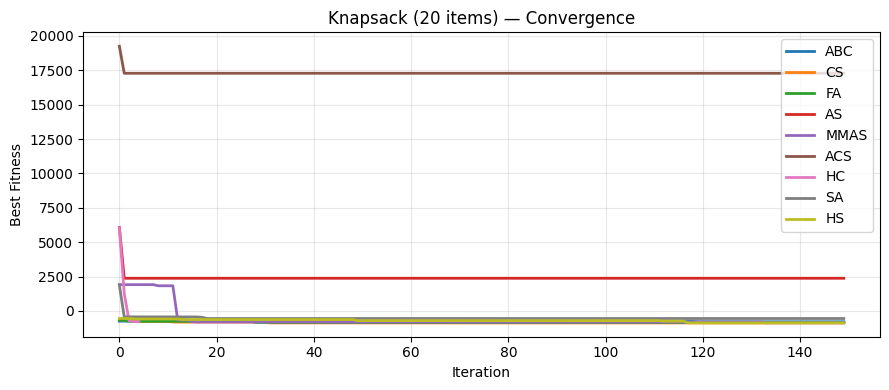

In [11]:
ks_results = [
    ('ABC',  abc_ks.history),
    ('CS',   cs_ks.history),
    ('FA',   fa_ks.history),
    ('AS',   as_ks.history),
    ('MMAS', mmas_ks.history),
    ('ACS',  acs_ks.history),
    ('HC',   hc_ks.history),
    ('SA',   sa_ks.history),
    ('HS',   hs_ks.history),
]
plot_convergence(ks_results, knapsack,
                 title='Knapsack (20 items) — Convergence')

### 2.3 Best Solution — Item Selection

A heatmap showing which items each algorithm selects in its best solution.
Rows are algorithms, columns are items. A filled cell means the item is packed.

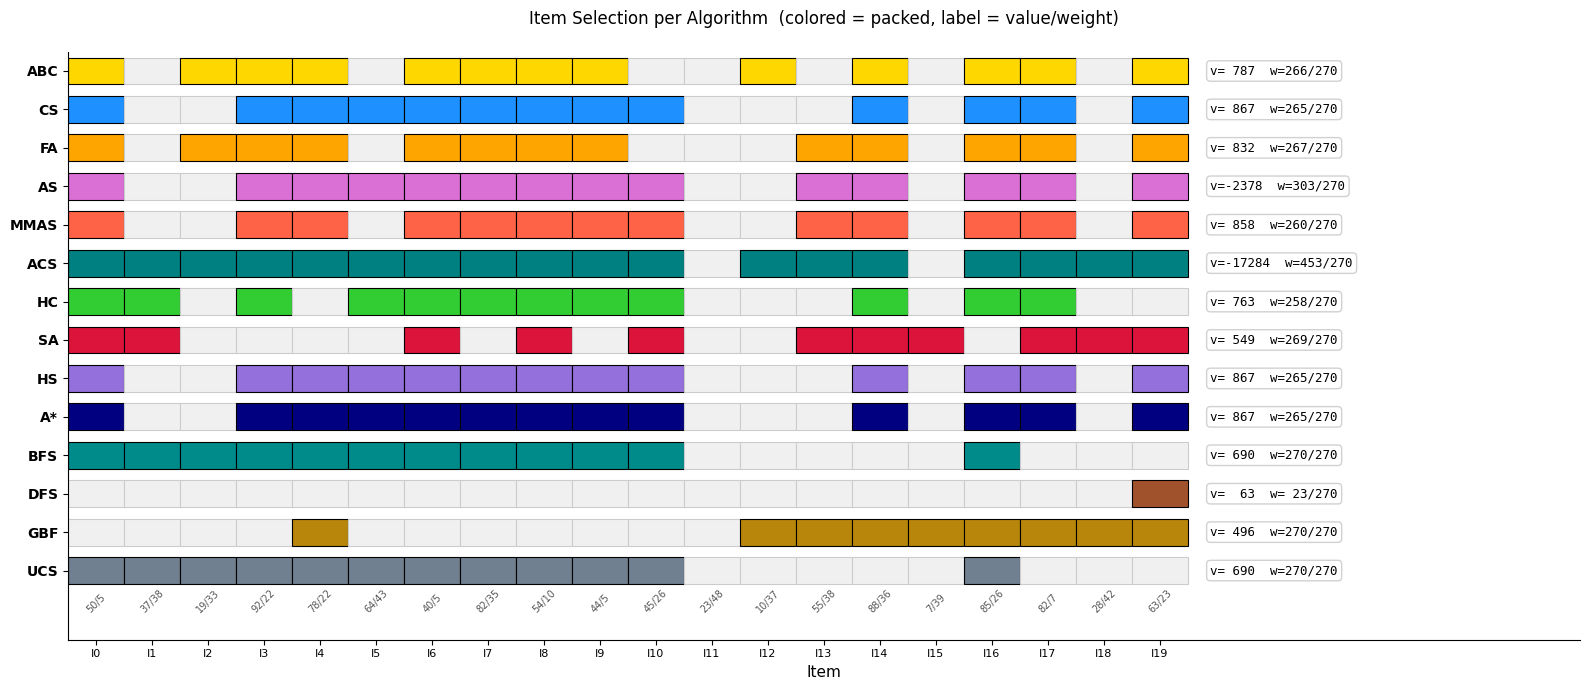

In [12]:
from types import SimpleNamespace

# Wrap classical solutions into algo-like objects for uniform handling
_classical_ks = [
    ('A*',  astar_ks_sol,  astar_ks_fit),
    ('BFS', bfs_ks_sol,    bfs_ks_fit),
    ('DFS', dfs_ks_sol,    dfs_ks_fit),
    ('GBF', gbf_ks_sol,    gbf_ks_fit),
    ('UCS', ucs_ks_sol,    ucs_ks_fit),
]
classical_ks_objs = []
for name, sol, fit in _classical_ks:
    obj = SimpleNamespace(best_solution=sol, best_fitness=fit)
    classical_ks_objs.append((name, obj))

ks_algos = [
    ('ABC',  abc_ks, 'gold'),       ('CS',   cs_ks,   'dodgerblue'),
    ('FA',   fa_ks,  'orange'),     ('AS',   as_ks,   'orchid'),
    ('MMAS', mmas_ks,'tomato'),     ('ACS',  acs_ks,  'teal'),
    ('HC',   hc_ks,  'limegreen'),  ('SA',   sa_ks,   'crimson'),
    ('HS',   hs_ks,  'mediumpurple'),
    ('A*',   classical_ks_objs[0][1], 'navy'),
    ('BFS',  classical_ks_objs[1][1], 'darkcyan'),
    ('DFS',  classical_ks_objs[2][1], 'sienna'),
    ('GBF',  classical_ks_objs[3][1], 'darkgoldenrod'),
    ('UCS',  classical_ks_objs[4][1], 'slategray'),
]

n_algos = len(ks_algos)
n_items = knapsack.n_items

fig, ax = plt.subplots(figsize=(16, 7))

bar_h = 0.7  # bar height per row
for row, (name, algo, color) in enumerate(ks_algos):
    sel = algo.best_solution.astype(bool)
    for j in range(n_items):
        fc = color if sel[j] else '#f0f0f0'
        ec = 'black' if sel[j] else '#cccccc'
        ax.add_patch(plt.Rectangle(
            (j, row - bar_h / 2), 1, bar_h,
            facecolor=fc, edgecolor=ec, linewidth=0.8))

    # Summary annotation on the right — outside the grid
    total_v = float(-knapsack.eval(algo.best_solution))
    total_w = float(np.dot(algo.best_solution, knapsack.weights))
    ax.text(n_items + 0.4, row,
            f'v={total_v:>4.0f}  w={total_w:>3.0f}/{knapsack.capacity:.0f}',
            va='center', ha='left', fontsize=9, fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#cccccc', alpha=0.9))

# Item value/weight labels on top
for j in range(n_items):
    ax.text(j + 0.5, n_algos + 0.15,
            f'{knapsack.values[j]:.0f}/{knapsack.weights[j]:.0f}',
            ha='center', va='bottom', fontsize=7, color='#555555', rotation=45)

ax.set_xlim(0, n_items + 7)
ax.set_ylim(-0.5, n_algos + 0.8)
ax.set_yticks(range(n_algos))
ax.set_yticklabels([name for name, _, _ in ks_algos], fontsize=10, fontweight='bold')
ax.set_xticks(np.arange(n_items) + 0.5)
ax.set_xticklabels([f'I{i}' for i in range(n_items)], fontsize=8)
ax.set_xlabel('Item', fontsize=11)
ax.set_title('Item Selection per Algorithm  (colored = packed, label = value/weight)',
             fontsize=12, pad=20)
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### 2.4 Value-Weight Scatter (Animated)

Each item plotted by weight (x) vs value (y). Flip through each algorithm
to see which items it packs (green) vs skips (gray).

In [13]:
def animate_knapsack_scatter(ks_algos, knapsack):
    """Animated scatter: flip through each algorithm's item selection."""
    fig, ax = plt.subplots(figsize=(8, 5))
    w, v = knapsack.weights, knapsack.values
    
    scat = ax.scatter(w, v, s=100, c='lightgray', edgecolors='gray', zorder=3)
    annotations = []
    for i in range(knapsack.n_items):
        ann = ax.annotate(f'I{i}', (w[i], v[i]),
                          textcoords='offset points', xytext=(5, 5), fontsize=7)
        annotations.append(ann)

    ax.set_xlabel('Weight', fontsize=11)
    ax.set_ylabel('Value', fontsize=11)
    ax.grid(True, alpha=0.3)
    title = ax.set_title('', fontsize=12, y=0.98)
    plt.tight_layout()
    # Legend patches (static)
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='forestgreen',
               markeredgecolor='black', markersize=10, label='Packed'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
               markeredgecolor='gray', markersize=10, label='Not packed'),
    ]
    ax.legend(handles=legend_elements, loc='upper left')

    def update(frame):
        name, algo, color = ks_algos[frame]
        sel = algo.best_solution.astype(bool)
        colors = np.where(sel, color, '#d3d3d3')
        edge_colors = np.where(sel, 'black', '#aaaaaa')
        sizes = np.where(sel, 140, 80)
        scat.set_facecolors(colors)
        scat.set_edgecolors(edge_colors)
        scat.set_sizes(sizes)

        total_v = float(-knapsack.eval(algo.best_solution))
        total_w = float(np.dot(algo.best_solution, knapsack.weights))
        title.set_text(
            f'{name}  —  value = {total_v:.0f},  '
            f'weight = {total_w:.0f} / {knapsack.capacity:.0f}')
        return scat, title

    anim = FuncAnimation(fig, update, frames=len(ks_algos),
                         interval=1000, repeat=True)
    plt.close(fig)
    return HTML(anim.to_jshtml())


animate_knapsack_scatter(ks_algos, knapsack)

---
# 3. Graph Coloring

We use the **small** instance (Petersen graph — 10 vertices, 3 colors).

In [14]:
gc = GraphColoring.create_small()
print(f'Vertices: {gc.n_vertices}   Colors: {gc.n_colors}')
print(f'Edges: {gc.edges}')

Vertices: 10   Colors: 3
Edges: [(0, 1), (0, 4), (0, 5), (1, 2), (1, 6), (2, 3), (2, 7), (3, 4), (3, 8), (4, 9), (5, 7), (5, 8), (6, 8), (6, 9), (7, 9)]


### 3.1 Run All Algorithms on Graph Coloring

In [16]:
N_ITER_GC = 150
np.random.seed(7)

# --- Swarm ---
abc_gc = ArtificialBeeColony(
    ABCParameter(n_bees=30, limit=50, iteration=N_ITER_GC), gc, stat=True
)
abc_gc.run()
print(f"ABC   conflicts = {abc_gc.best_fitness:.0f}")

cs_gc = CuckooSearch(
    CuckooSearchParameter(
        n_nests=30, pa=0.25, alpha=0.01, beta=1.5, iteration=N_ITER_GC
    ),
    gc,
    stat=True,
)
cs_gc.run()
print(f"CS    conflicts = {cs_gc.best_fitness:.0f}")

fa_gc = FireflyAlgorithm(
    FireflyParameter(
        n_fireflies=30,
        alpha=0.5,
        beta0=1.0,
        gamma=1.0,
        alpha_decay=0.97,
        cycle=N_ITER_GC,
    ),
    gc,
    stat=True,
)
fa_gc.run()
print(f"FA    conflicts = {fa_gc.best_fitness:.0f}")

# --- ACO ---
as_gc = AntSystem(
    AntSystemParameter(rho=0.5, m=20, q=100, alpha=1, beta=2, cycle=N_ITER_GC), gc
)
as_gc.run()
print(f"AS    conflicts = {as_gc.best_fitness:.0f}")

mmas_gc = MMAS(MMASParameter(rho=0.02, m=20, alpha=1, beta=2, cycle=N_ITER_GC), gc)
mmas_gc.run()
print(f"MMAS  conflicts = {mmas_gc.best_fitness:.0f}")

acs_gc = ACS(
    ACSParameter(rho=0.1, xi=0.1, m=20, q0=0.9, alpha=1, beta=2, cycle=N_ITER_GC), gc
)
acs_gc.run()
print(f"ACS   conflicts = {acs_gc.best_fitness:.0f}")

# --- Local search ---
hc_gc = HillClimbing(HillClimbingParameter(iteration=N_ITER_GC), gc)
hc_gc.run()
print(f"HC    conflicts = {hc_gc.best_fitness:.0f}")

# --- Physics-inspired ---
sa_gc = SimulatedAnnealing(
    SimulatedAnnealingParameter(
        initial_temperature=100,
        cooling_rate=0.95,
        min_temperature=0.01,
        max_iterations=N_ITER_GC,
        n_flips=1,
    ),
    gc,
)
sa_gc.run()
print(f"SA    conflicts = {sa_gc.best_fitness:.0f}")

hs_gc = HarmonySearch(
    HarmonySearchParameter(hms=30, hmcr=0.9, par=0.3, bw=0.1, max_iterations=N_ITER_GC),
    gc,
)
hs_gc.run()
print(f"HS    conflicts = {hs_gc.best_fitness:.0f}")

# --- Classical search ---
astar_gc = AStarSearch({}, gc)
astar_gc.run()
astar_gc_sol, astar_gc_fit = extract_classical_solution(astar_gc, gc)
print(f"A*    conflicts = {astar_gc_fit:.0f}")

bfs_gc = BreadthFirstSearch({}, gc)
bfs_gc.run()
bfs_gc_sol, bfs_gc_fit = extract_classical_solution(bfs_gc, gc)
print(f"BFS   conflicts = {bfs_gc_fit:.0f}")

dfs_gc = DepthFirstSearch({}, gc)
dfs_gc.run()
dfs_gc_sol, dfs_gc_fit = extract_classical_solution(dfs_gc, gc)
print(f"DFS   conflicts = {dfs_gc_fit:.0f}")

gbf_gc = GreedyBestFirstSearch({}, gc)
gbf_gc.run()
gbf_gc_sol, gbf_gc_fit = extract_classical_solution(gbf_gc, gc)
print(f"GBF   conflicts = {gbf_gc_fit:.0f}")

ucs_gc = UniformCostSearch({}, gc)
ucs_gc.run()
ucs_gc_sol, ucs_gc_fit = extract_classical_solution(ucs_gc, gc)
print(f"UCS   conflicts = {ucs_gc_fit:.0f}")

ABC   conflicts = 0
CS    conflicts = 0
FA    conflicts = 0
AS    conflicts = 0
MMAS  conflicts = 0
ACS   conflicts = 0
HC    conflicts = 0
SA    conflicts = 0
HS    conflicts = 1
A*    conflicts = 0
BFS   conflicts = 15
DFS   conflicts = 12
GBF   conflicts = 15
UCS   conflicts = 0


### 3.2 Graph Coloring Convergence

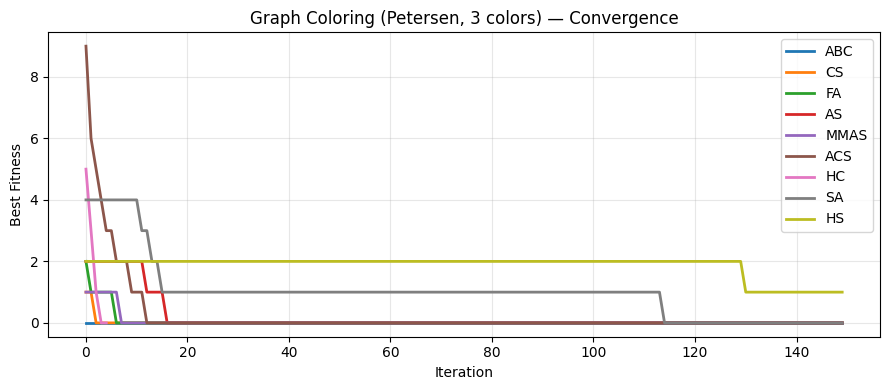

In [17]:
gc_results = [
    ('ABC',  abc_gc.history),
    ('CS',   cs_gc.history),
    ('FA',   fa_gc.history),
    ('AS',   as_gc.history),
    ('MMAS', mmas_gc.history),
    ('ACS',  acs_gc.history),
    ('HC',   hc_gc.history),
    ('SA',   sa_gc.history),
    ('HS',   hs_gc.history),
]
plot_convergence(gc_results, gc,
                 title='Graph Coloring (Petersen, 3 colors) — Convergence')

### 3.3 Best Coloring Visualization

Draw the graph with vertex colors from the best solution of each algorithm.
Conflicting edges (same color on both ends) are drawn in **red**.

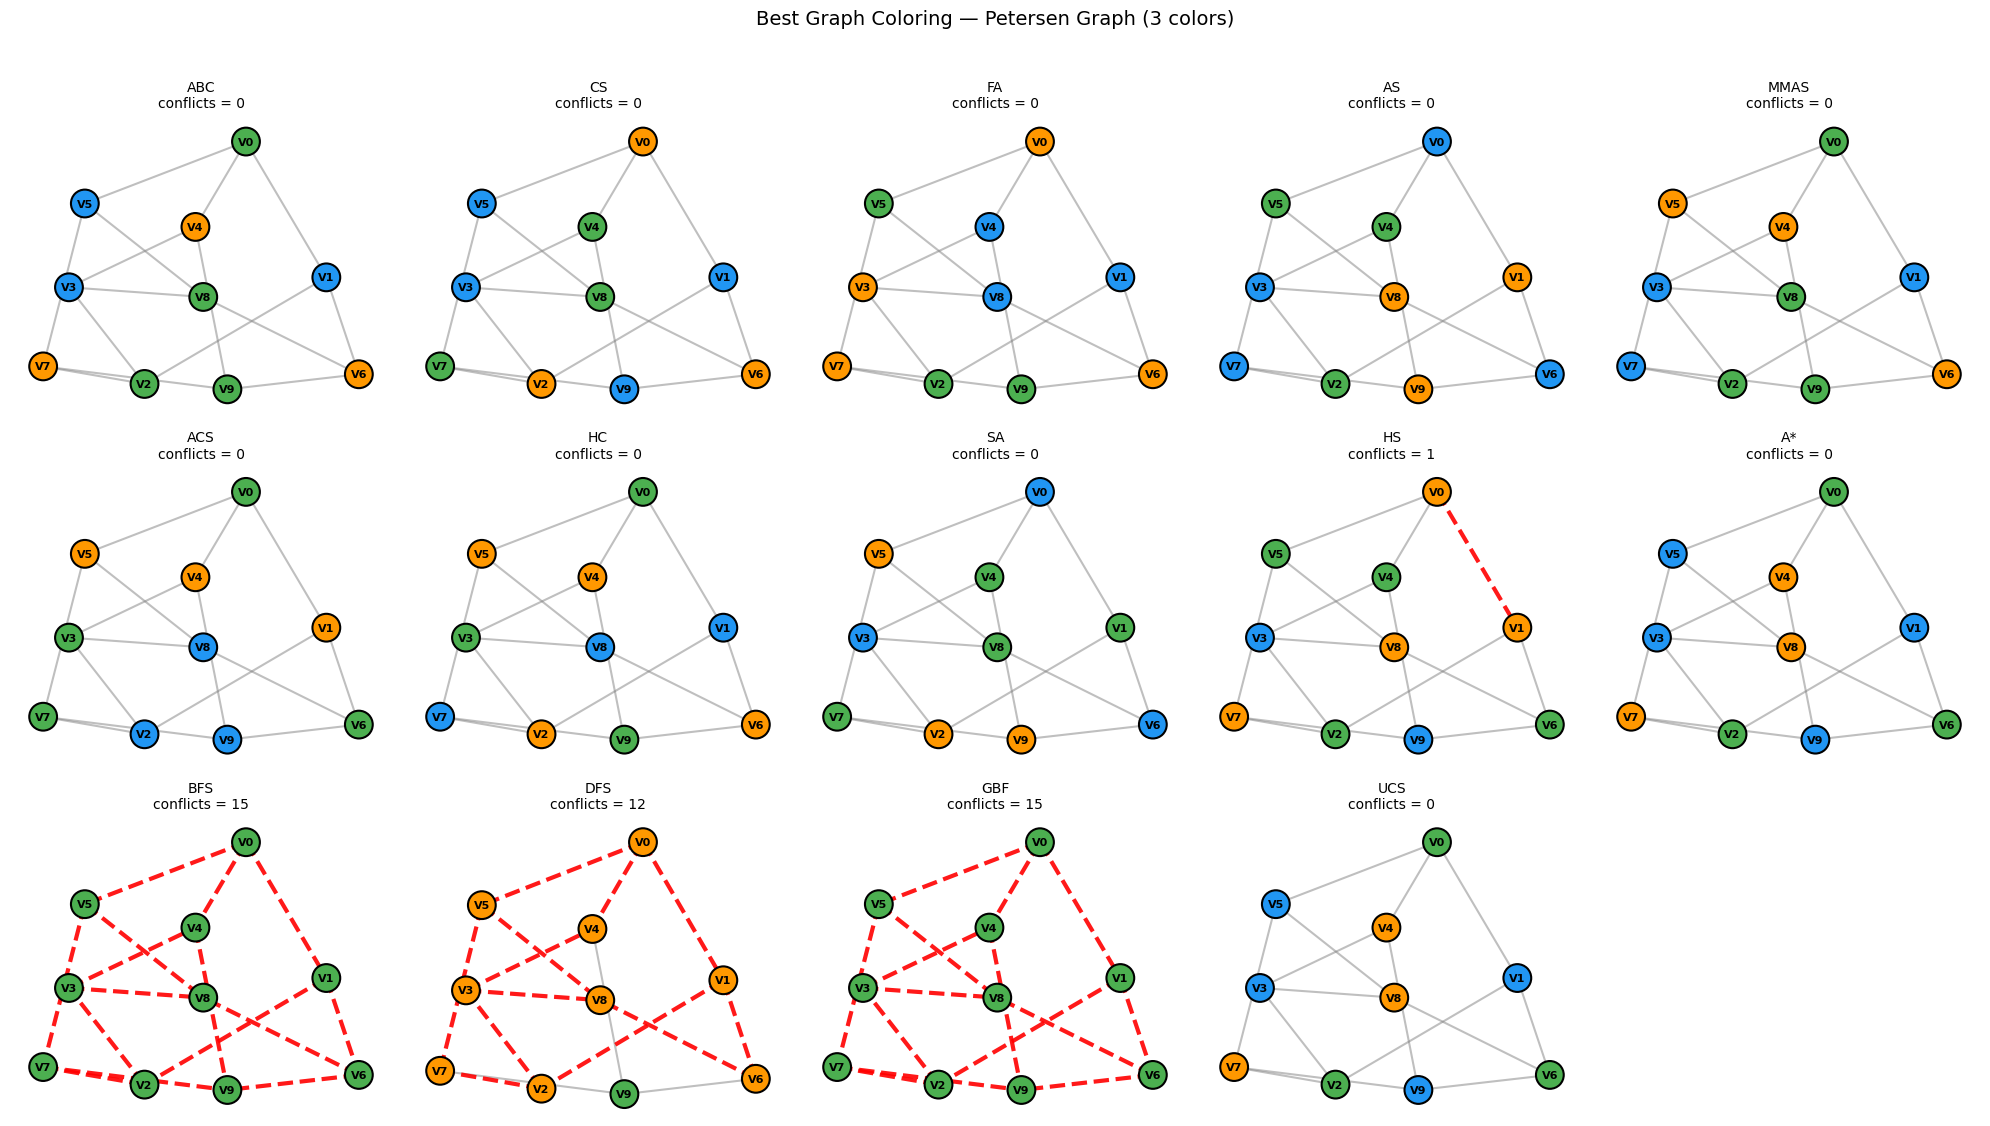

In [18]:
COLOR_PALETTE = ['#4CAF50', '#2196F3', '#FF9800', '#E91E63',
                 '#9C27B0', '#00BCD4', '#FFEB3B', '#795548']


def draw_graph_coloring(ax, solution, gc_problem, title=''):
    """Draw the graph with vertex colors and highlight conflicts."""
    G = nx.Graph()
    G.add_nodes_from(range(gc_problem.n_vertices))
    G.add_edges_from(gc_problem.edges)
    pos = nx.spring_layout(G, seed=42)

    sol = solution.astype(int)
    node_colors = [COLOR_PALETTE[sol[v] % len(COLOR_PALETTE)]
                   for v in range(gc_problem.n_vertices)]

    # Classify edges as conflict or OK
    conflict_edges = [(u, v) for u, v in gc_problem.edges if sol[u] == sol[v]]
    ok_edges = [(u, v) for u, v in gc_problem.edges if sol[u] != sol[v]]

    nx.draw_networkx_edges(G, pos, edgelist=ok_edges, ax=ax,
                          edge_color='gray', width=1.5, alpha=0.5)
    nx.draw_networkx_edges(G, pos, edgelist=conflict_edges, ax=ax,
                          edge_color='red', width=3, alpha=0.9, style='dashed')
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                          node_size=400, edgecolors='black', linewidths=1.5)
    labels = {i: gc_problem.vertex_names[i] for i in range(gc_problem.n_vertices)}
    nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=8,
                           font_weight='bold')

    n_conflicts = int(gc_problem.eval(solution))
    ax.set_title(f'{title}\nconflicts = {n_conflicts}', fontsize=10)
    ax.axis('off')


gc_algos = [
    ('ABC',  abc_gc.best_solution),  ('CS',  cs_gc.best_solution),
    ('FA',   fa_gc.best_solution),   ('AS',  as_gc.best_solution),
    ('MMAS', mmas_gc.best_solution), ('ACS', acs_gc.best_solution),
    ('HC',   hc_gc.best_solution),   ('SA',  sa_gc.best_solution),
    ('HS',   hs_gc.best_solution),
    ('A*',   astar_gc_sol),          ('BFS', bfs_gc_sol),
    ('DFS',  dfs_gc_sol),            ('GBF', gbf_gc_sol),
    ('UCS',  ucs_gc_sol),
]

n_cols = 5
n_rows = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 11))
axes = axes.flatten()
for idx, (name, sol) in enumerate(gc_algos):
    draw_graph_coloring(axes[idx], sol, gc, title=name)
# Hide unused subplot
axes[-1].axis('off')

fig.suptitle('Best Graph Coloring — Petersen Graph (3 colors)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
# 4. Summary — Final Fitness Comparison (Bar Chart)

Side-by-side bar chart of the best fitness achieved by each algorithm
across all three problems. Fitness is computed via `problem.eval()`
for consistent comparison.

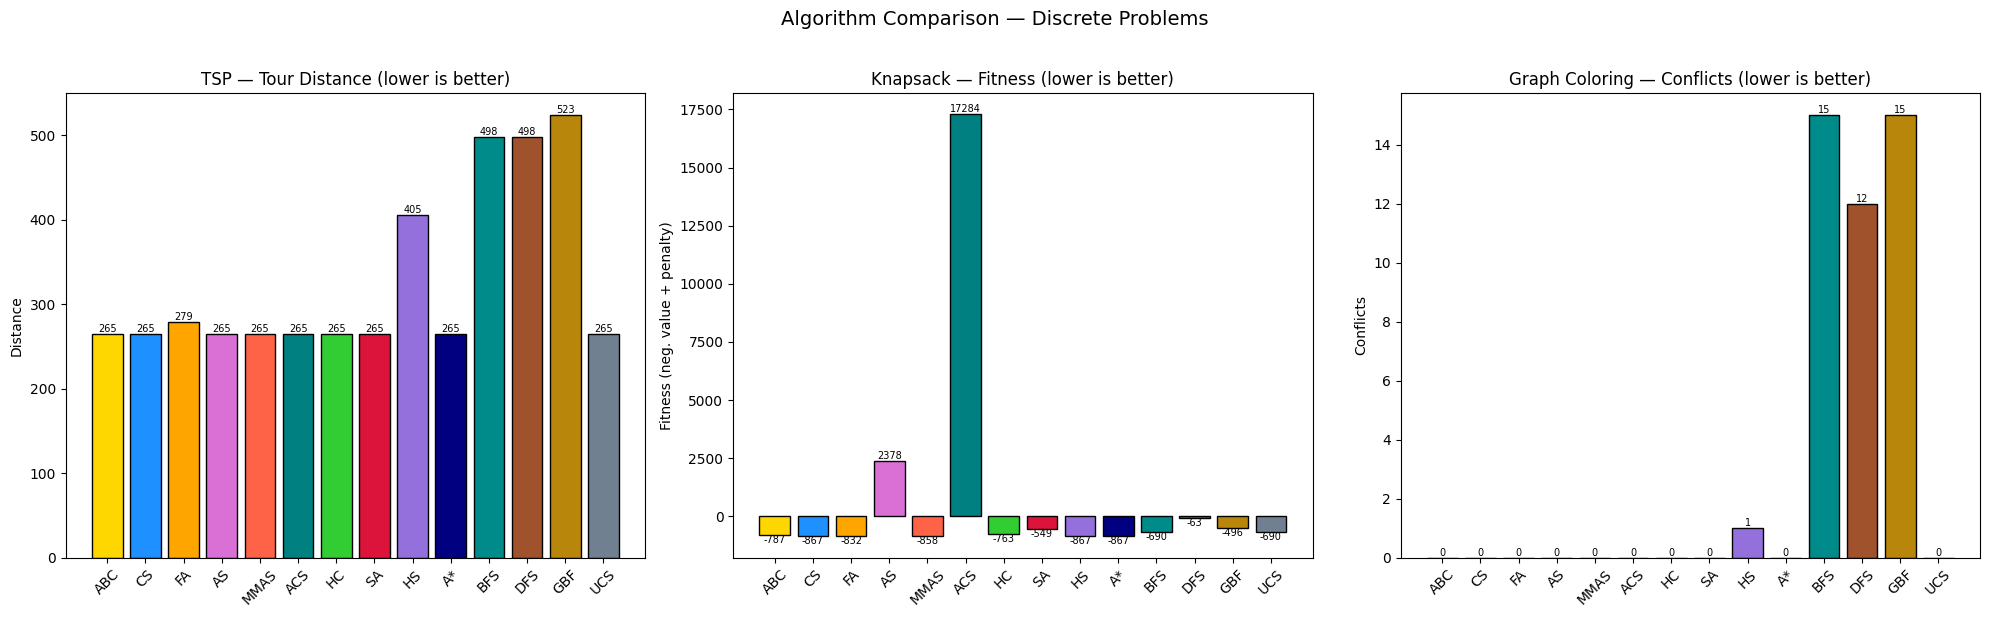

In [19]:
algo_names = ['ABC', 'CS', 'FA', 'AS', 'MMAS', 'ACS',
              'HC', 'SA', 'HS', 'A*', 'BFS', 'DFS', 'GBF', 'UCS']

# Collect TSP fitnesses (eval for consistency)
_tsp_sols = [abc_tsp.best_solution, cs_tsp.best_solution, fa_tsp.best_solution,
             as_tsp.best_solution, mmas_tsp.best_solution, acs_tsp.best_solution,
             hc_tsp.best_solution, sa_tsp.best_solution, hs_tsp.best_solution,
             astar_tsp_sol, bfs_tsp_sol, dfs_tsp_sol, gbf_tsp_sol, ucs_tsp_sol]
tsp_fits = [float(tsp.eval(s)) for s in _tsp_sols]

# Collect KS fitnesses
_ks_sols = [abc_ks.best_solution, cs_ks.best_solution, fa_ks.best_solution,
            as_ks.best_solution, mmas_ks.best_solution, acs_ks.best_solution,
            hc_ks.best_solution, sa_ks.best_solution, hs_ks.best_solution,
            astar_ks_sol, bfs_ks_sol, dfs_ks_sol, gbf_ks_sol, ucs_ks_sol]
ks_fits = [float(knapsack.eval(s)) for s in _ks_sols]

# Collect GC fitnesses
_gc_sols = [abc_gc.best_solution, cs_gc.best_solution, fa_gc.best_solution,
            as_gc.best_solution, mmas_gc.best_solution, acs_gc.best_solution,
            hc_gc.best_solution, sa_gc.best_solution, hs_gc.best_solution,
            astar_gc_sol, bfs_gc_sol, dfs_gc_sol, gbf_gc_sol, ucs_gc_sol]
gc_fits = [float(gc.eval(s)) for s in _gc_sols]

colors = ['gold', 'dodgerblue', 'orange', 'orchid', 'tomato', 'teal',
          'limegreen', 'crimson', 'mediumpurple',
          'navy', 'darkcyan', 'sienna', 'darkgoldenrod', 'slategray']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].bar(algo_names, tsp_fits, color=colors, edgecolor='black')
axes[0].set_title('TSP — Tour Distance (lower is better)')
axes[0].set_ylabel('Distance')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(tsp_fits):
    axes[0].text(i, v, f'{v:.0f}', ha='center', va='bottom', fontsize=7)

axes[1].bar(algo_names, ks_fits, color=colors, edgecolor='black')
axes[1].set_title('Knapsack — Fitness (lower is better)')
axes[1].set_ylabel('Fitness (neg. value + penalty)')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(ks_fits):
    axes[1].text(i, v, f'{v:.0f}', ha='center',
               va='bottom' if v >= 0 else 'top', fontsize=7)

axes[2].bar(algo_names, gc_fits, color=colors, edgecolor='black')
axes[2].set_title('Graph Coloring — Conflicts (lower is better)')
axes[2].set_ylabel('Conflicts')
axes[2].tick_params(axis='x', rotation=45)
for i, v in enumerate(gc_fits):
    axes[2].text(i, v, f'{v:.0f}', ha='center', va='bottom', fontsize=7)

fig.suptitle('Algorithm Comparison — Discrete Problems', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()